![logo](./img/LogoLine_horizon_C3S.png)

## Getting and plotting 2m temperature from CARRA-West and ERA5

CARRA and ERA5 data can be found in the CDS (Copernicus Climate Data Store, https://cds.climate.copernicus.eu/cdsapp#!/home).
The CARRA entries are at https://cds.climate.copernicus.eu/cdsapp#!/search?text=CARRA.
The complete ERA5 entry is  https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-complete?tab=overview.
Here the CARRA single levels are chosen for the 2m temperature (and to limit the size of the data).
You need to create an account and accept the terms and conditions for all datasets that you want to use.


### Fetching CARRA and ERA5 data
The source code will download a specific month. By specifying the start and end date below one can easily download longer periods. We are selecting 2m temperature, which is in the single level CDS entry. 
Here, we download the 3-hourly analysis time steps and the data will be stored in a specified file.
For more details on ERA5 data download please see the [CDS tutorials in this link](https://github.com/ecmwf-projects/copernicus-training-c3s)


![logo](./img/climatology_banner.png)

<style>
td, th {
   border: 1px solid white;
   border-collapse: collapse;
}
</style>
<table align="left">
  <tr>
    <th>
      To run the notebooks in the cloud environment click on the icons for "binder" or "kaggle" or "colab" in the menubar below.<br><br>
      <div>
        <a href="https://mybinder.org/v2/gh/ecmwf-projects/copernicus-training-c3s/main?labpath=reanalysis-climatology.ipynb">
          <img src="https://mybinder.org/badge.svg" alt="Binder">
        </a>
        <a href="https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-projects/copernicus-training-c3s/blob/main/reanalysis-climatology.ipynb">
          <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Kaggle">
        </a>
        <a href="https://colab.research.google.com/github/ecmwf-projects/copernicus-training-c3s/blob/main/reanalysis-climatology.ipynb">
          <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Colab">
        </a>
      </div>
    </th>
  </tr>
</table>


#### Install CDS API

Before we begin we must prepare our environment. This includes installing the Application Programming Interface (API) of the CDS, and importing the various python libraries that we will need.

To install the CDS API, run the following command. We use an exclamation mark to pass the command to the shell (not to the Python interpreter).

In [62]:
#!pip install cdsapi #Uncomment this part if cdsapi is not installed

#### Enter your CDS API key
 
We will request data from the Climate Data Store (CDS) programmatically with the help of the CDS API. Let us make use of the option to manually set the CDS API credentials. First, you have to define two variables: URL and KEY which build together your CDS API key. The string of characters that make up your KEY include your personal User ID and CDS API key. To obtain these, first register or login to the CDS (http://cds.climate.copernicus.eu), then visit https://cds.climate.copernicus.eu/api-how-to and copy the string of characters listed after “key:”. Replace the ######### below with this string. 

In [63]:
URL = 'https://cds.climate.copernicus.eu/api/v2'
KEY = '##################################' 

In [64]:
import os
import cdsapi
import warnings
warnings.filterwarnings('ignore') #turn off some warnings
import cdsapi
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [65]:
# Here one specifies the domain, year and period to download

yearStart = 2024 #first year to download
yearEnd   = 2024 #last year to download
monthStart =  3 # first month to download
monthEnd   =  3 #last month to download
days = [str(i).zfill(2) for i in range(1,31)] # the list of days to download. Adapt day number for other months
domain = 'west_domain' # the domain to select. Use "east_domain" for the East domain
period="202403" # the period to plot

#Below a polygon to limit the area downloaded from ERA5, otherwise it will download the whole world
area_for_era5 = [90, -110, 55, 40] #WEST domain polygon, format: North,West,South,East corners
#area_for_era5 = [85,0,60,50]: EAST domain polygon

# Files where dara will be downloaded
fCARRA = os.path.join("CARRA","Raw_data","T2m_an_"+period+".grb")
fERA5 = os.path.join("ERA5","Raw_data","era5_t2m_"+period+".grb")

#Call the CDS client
c = cdsapi.Client(url=URL,key=KEY )


### Helper functions to download the data

In [66]:
#setup the directories and the file names to output the data
DATADIR="CARRA"
# create directory to store CARRA data if it does not exist already:
if not os.path.isdir(DATADIR):
    os.makedirs(os.path.join(DATADIR,"Raw_data"))
   
fCARRA = os.path.join(DATADIR,"Raw_data","T2m_an_"+period+".grb")

DATADIR="ERA5"
# create directory to store CARRA data if it does not exist already:
if not os.path.isdir(DATADIR):
    os.makedirs(os.path.join(DATADIR,"Raw_data"))
    
fERA5 = os.path.join(DATADIR,"Raw_data","T2m_an_"+period+".nc")

# define a helper function to download the data
# Note that the time is hardcoded since we are selecting
# all possible available times. 
def fetch_month_carra(month, year, days, domain,fout):
    c.retrieve(
        'reanalysis-carra-single-levels',
        {
            'format': 'grib',
            'domain': domain ,
            'level_type': 'surface_or_atmosphere',
            'variable': '2m_temperature',
            'product_type': 'analysis',
            'year': year,
            'month': month,
            'day': days,
            'time': [
                '00:00', '03:00', '06:00',
                '09:00', '12:00', '15:00',
                '18:00', '21:00',
            ],
        },
        fout)
    

# Help function to download ERA5 data
def fetch_month_era5(month, year, days, area,fout):
    c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': '2m_temperature',
        'year': str(year),
        'month': str(month).zfill(2),
        'day': days,
        'time': [
            '00:00', '03:00', '06:00',
            '09:00', '12:00', '15:00',
            '18:00', '21:00',
        ],
        'area': area,
        'format': 'netcdf',
    },
     fout)
    

### Fetch the CARRA West data

In [67]:
# Loop through the period selected
for year in list(range(yearStart, yearEnd + 1)):
    for month in list(range(1,13)):
        if year == yearStart and month < monthStart:
            # Before the start date.
            continue
        if year == yearEnd and month > monthEnd:
            # After end date.
            break

        print ("CARRA data will be fetched for ", year, month)
        print("This will take a few minutes, depending on the data size (~621 MB for west, ~357 MB for east case)")
        fetch_month_carra(month, year, days, domain,fCARRA)

CARRA data will be fetched for  2024 3
This will take a few minutes, depending on the data size (~621 MB for west, ~357 MB for east case)


2024-08-20 15:32:17,363 INFO Welcome to the CDS.
 As per our announcements on the Forum, this instance of CDS will soon be decommissioned.
 Please update your cdsapi package to a version >=0.7.0, create an account on CDS-Beta and update your .cdsapirc file. We strongly recommend users to check our Guidelines at https://confluence.ecmwf.int/x/uINmFw
 The current legacy system will be kept for a while, but we will reduce resources gradually until full decommissioning in September 2024.
2024-08-20 15:32:17,364 WARNING MOVE TO CDS-Beta
2024-08-20 15:32:17,366 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-carra-single-levels
2024-08-20 15:32:17,593 INFO Request is completed
2024-08-20 15:32:17,595 INFO Downloading https://download-0011-clone.copernicus-climate.eu/cache-compute-0011/cache/data2/adaptor.mars.external-1724150388.8096566-11050-18-133048a1-0220-42ed-9756-f2d91f34e93b.grib to CARRA/Raw_data/T2m_an_202403.grb (621.2M)
2024-08-20 15:35:10,890

### Fetch the ERA5 data

In [68]:
# Loop through the period selected
for year in list(range(yearStart, yearEnd + 1)):
    for month in list(range(1,13)):
        if year == yearStart and month < monthStart:
            # Before the start date.
            continue
        if year == yearEnd and month > monthEnd:
            # After end date.
            break

        print ("ERA5 data will be fetched for ", year, month)
        print("This will take a few minutes, depending on the data size (~39 MB for west area)")
        fetch_month_era5(month, year, days, area_for_era5,fERA5)

ERA5 data will be fetched for  2024 3
This will take a few minutes, depending on the data size (~39 MB for west area)


2024-08-20 15:40:04,947 INFO Welcome to the CDS.
 As per our announcements on the Forum, this instance of CDS will soon be decommissioned.
 Please update your cdsapi package to a version >=0.7.0, create an account on CDS-Beta and update your .cdsapirc file. We strongly recommend users to check our Guidelines at https://confluence.ecmwf.int/x/uINmFw
 The current legacy system will be kept for a while, but we will reduce resources gradually until full decommissioning in September 2024.
2024-08-20 15:40:04,948 WARNING MOVE TO CDS-Beta
2024-08-20 15:40:04,948 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels
2024-08-20 15:40:05,217 INFO Downloading https://download-0010-clone.copernicus-climate.eu/cache-compute-0010/cache/data2/adaptor.mars.internal-1724153464.5306163-31157-6-ffd95c15-a0a6-4b92-a056-bb55f9d77f34.nc to ERA5/Raw_data/T2m_an_202403.nc (38.8M)
2024-08-20 15:40:26,293 INFO Download rate 1.8M/s                               

# Plotting the CARRA and ERA5 data

## Interpolate data to a common grid
Before plotting the two data sets we need to have them first in the same grid.
We use the [CDO library](https://code.mpimet.mpg.de/projects/cdo/wiki) to interpolate the ERA5 data
into the CARRA West grid for a fair comparison. 
After importing the CDOs into python it is one line to interpolate between the grids.
Note that CDO can handle both GRIB format and NetCDF data. For instance, CARRA is downloaded in GRIB whereas we downloaded ERA5 as NetCDF.

More information regarding the CDOs (Climate data operators) can be found at https://code.mpimet.mpg.de/projects/cdo

The interpolation/projection can also be done using the [pyresample](https://pyresample.readthedocs.io/en/latest/howtos/swath.html) library.

In [69]:
#function to interpolate ERA5 data to the CARRA grid using cdo
from cdo import *
def interpol_cdo(input_grid,output_grid,output_file):
    cdo   = Cdo()
    #This function call takes the grid input from CARRA and projects the ERA4 file into the CARRA grid
    cdo.remapbil(input_grid, input=output_grid, output=output_file)
# This is where the output from the ERA5 data interpolated to the CARRA grid
fERA5_CARRA_grid = os.path.join("ERA5","era5_t2m_"+period+"_CARRA_grid.nc")
interpol_cdo(fCARRA,fERA5,fERA5_CARRA_grid)


## Plotting the data
Compute the mean 2m temperature over the whole month.
First we open the data sets using xarray and then calculate the mean over the whole month.


In [70]:
# Open the data sets to plot using xarray

import xarray as xr

# Open Datasets
CARRA = xr.open_dataset(fCARRA)
ERA5  = xr.open_dataset(fERA5_CARRA_grid)

# Compute monthly mean
print("Computing the mean for CARRA and ERA5...")
CARRA_mean = CARRA.mean(dim="time", keep_attrs=True)
ERA5_mean = ERA5.mean(dim="time", keep_attrs=True)
print("Done.")

# Change longitudes from 0-360 to -180 to 180, needed for the plotting
CARRA_mean = CARRA_mean.assign_coords(longitude=(((CARRA_mean.longitude + 180) % 360) - 180))
ERA5_mean = ERA5_mean.assign_coords(longitude=CARRA_mean.longitude)

# Change unit from K to C and add the unit to the attributes
CARRA_mean_C = CARRA_mean - 273.15
CARRA_mean_C = CARRA_mean_C.assign_attrs(CARRA_mean.attrs)
CARRA_mean_C.attrs['units'] = 'deg C'
ERA5_mean_C = ERA5_mean - 273.15
ERA5_mean_C = ERA5_mean_C.assign_attrs(ERA5_mean.attrs)
ERA5_mean_C.attrs['units'] = 'deg C'

Computing the mean for CARRA and ERA5...
Done.


### Plot for CARRA

Plotting CARRA mean surface temperature and saving the figure


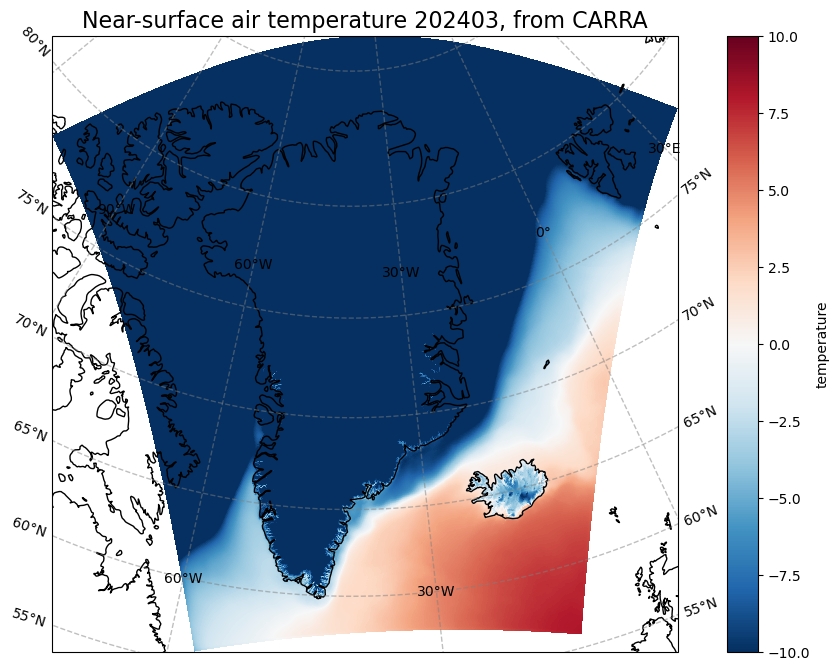

In [71]:
print("Plotting CARRA mean surface temperature and saving the figure")
# create the figure panel and the map using the Cartopy Lambert conformal projection
fig, ax = plt.subplots(1, 1, figsize = (16, 8), subplot_kw={'projection': ccrs.LambertConformal(central_latitude=70.0, central_longitude=-40.0)})

# Plot the data
im = plt.pcolormesh(CARRA_mean_C.longitude, CARRA_mean_C.latitude,CARRA_mean_C.t2m,
                    transform = ccrs.PlateCarree(), cmap='RdBu_r', vmin=-10, vmax=10)

# Set the figure title
ax.set_title('Near-surface air temperature '+period+', from CARRA', fontsize=16)
ax.coastlines(color='black')
ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--') 

# Specify the colourbar
cbar = plt.colorbar(im,fraction=0.05, pad=0.04)
cbar.set_label('temperature')

# Save the figure
FIGS=os.path.join(DATADIR,"Figures")
if not os.path.isdir(FIGS):
    os.makedirs(FIGS)
    
fig.savefig(f'{FIGS}/CARRA_T2m_map.png')

### Plot for ERA5

Plotting ERA5 mean surface temperature and saving the figure


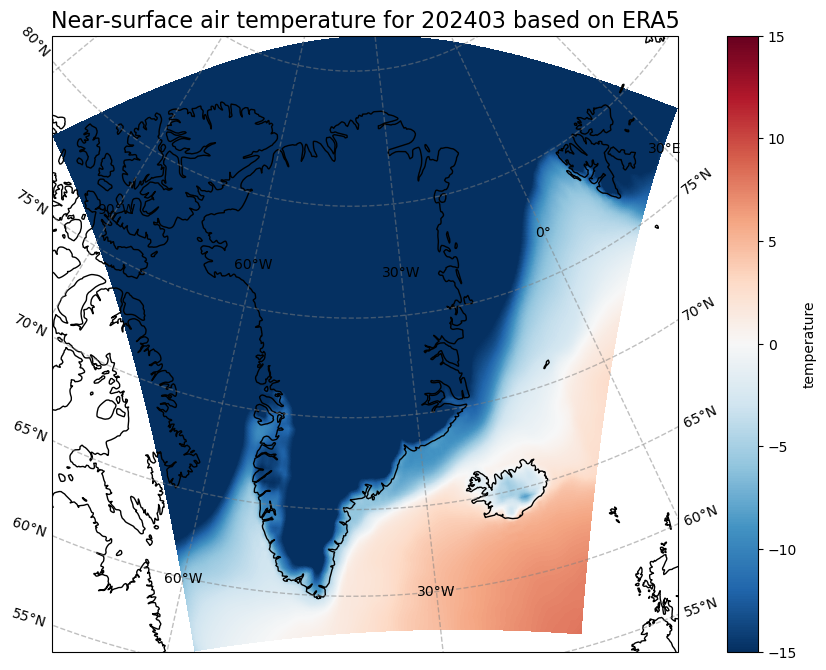

In [72]:

print("Plotting ERA5 mean surface temperature and saving the figure")

# create the figure panel and the map using the Cartopy Lambert conformal projection
fig, ax = plt.subplots(1, 1, figsize = (16, 8), subplot_kw={'projection': ccrs.LambertConformal(central_latitude=70.0, central_longitude=-40.0)})

# Plot the data
im = plt.pcolormesh(ERA5_mean_C.longitude, ERA5_mean_C.latitude, ERA5_mean_C.t2m, transform = ccrs.PlateCarree(), cmap='RdBu_r', vmin=-15, vmax=15)

# Set the figure title
ax.set_title('Near-surface air temperature for '+period+' based on ERA5', fontsize=16)
ax.coastlines(color='black')
ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--') 

# Specify the colourbar
cbar = plt.colorbar(im,fraction=0.05, pad=0.04)
cbar.set_label('temperature')

# Save the figure
if not os.path.isdir(os.path.join("ERA5","Figures")):
    os.makedirs(os.path.join(DATADIR,"Figures"))
fig.savefig(f'ERA5/Figures/ERA5_'+period+'_map.png')

### Plot the difference between CARRA and ERA5
Note that the differences are computed in the plotting command itself.

Plot the difference CARRA - ERA5


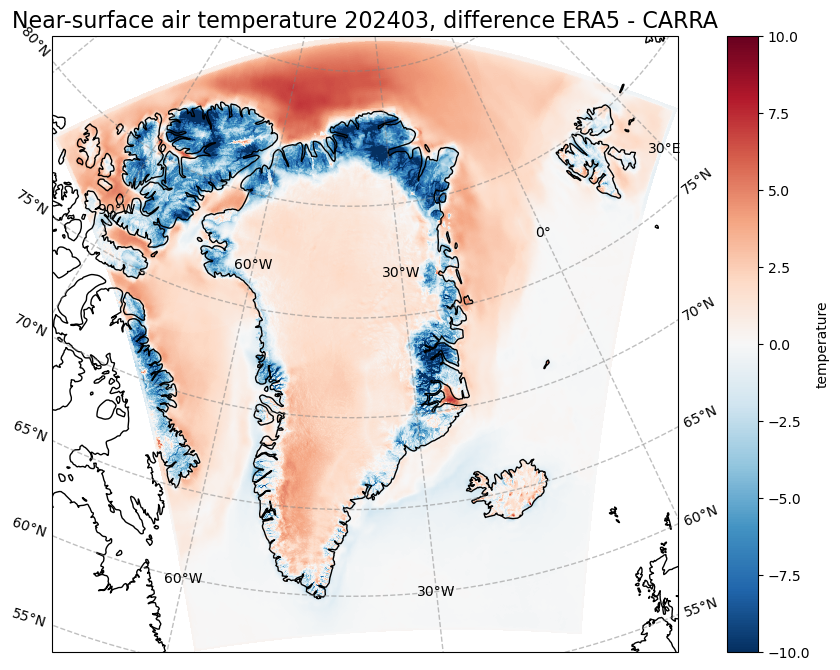

In [73]:
print("Plot the difference CARRA - ERA5")
# create the figure panel and the map using the Cartopy Lambert conformal projection
fig, ax = plt.subplots(1, 1, figsize = (16, 8), subplot_kw={'projection': ccrs.LambertConformal(central_latitude=70.0, central_longitude=-40.0)})

# Plot the data, the differences are computed directly in the line below.
im = plt.pcolormesh(CARRA_mean_C.longitude, CARRA_mean_C.latitude, ERA5_mean_C.t2m - CARRA_mean_C.t2m,
                    transform = ccrs.PlateCarree(), cmap='RdBu_r', vmin=-10, vmax=10)

# Set the figure title
ax.set_title('Near-surface air temperature '+period+', difference ERA5 - CARRA', fontsize=16)
ax.coastlines(color='black')
ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--') 

# Specify the colourbar
cbar = plt.colorbar(im,fraction=0.05, pad=0.04)
cbar.set_label('temperature')

# Save the figure
if not os.path.isdir(os.path.join("CARRA","Figures")):
    os.makedirs(os.path.join("CARRA","Figures"))
fig.savefig(f'CARRA/Figures/ERA5-CARRA_map.png')